# Кластеризация

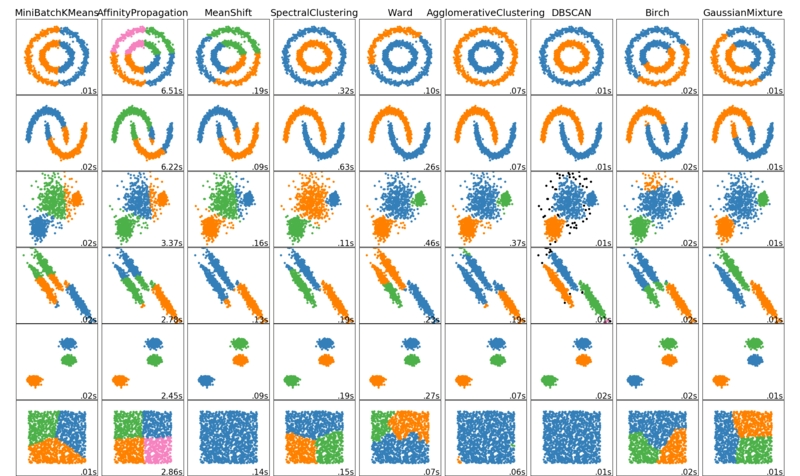

## Сгенерируем точки из трех кластеров

In [25]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from scipy.cluster import hierarchy
from scipy.spatial.distance import pdist

import numpy as np
from matplotlib import pylab as plt

import warnings
warnings.filterwarnings("ignore")

Text(0, 0.5, 'y')

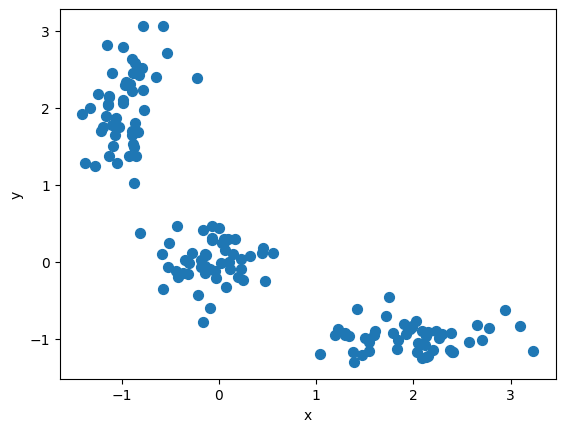

In [6]:
X = np.zeros((150, 2))

np.random.seed(seed = 42)
X[:50, 0] = np.random.normal(loc = 0.0, scale = .3, size = 50)
X[:50, 1] = np.random.normal(loc = 0.0, scale = .3, size = 50)

X[50:100, 0] = np.random.normal(loc = 2.0, scale = .5, size = 50)
X[50:100, 1] = np.random.normal(loc = -1.0, scale = .2, size = 50)

X[100:150, 0] = np.random.normal(loc = -1.0, scale = .2, size = 50)
X[100:150, 1] = np.random.normal(loc = 2.0, scale = .5, size = 50)

plt.scatter(X[...,0], X[...,1], s = 50, cmap = 'viridis')
plt.xlabel('x')
plt.ylabel('y')

## Применим **K-means**

[Ссылка на визуализацию K-Means](https://www.naftaliharris.com/blog/visualizing-k-means-clustering/)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 2 2 2 2 2 2 2 2
 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


Text(0, 0.5, 'y')

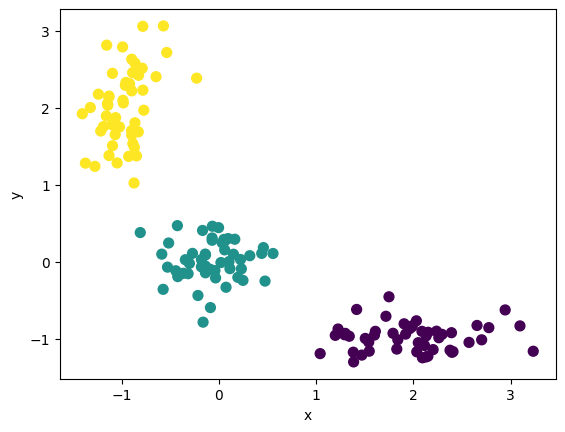

In [21]:
kmeans = KMeans(n_clusters=3, random_state=1)
kmeans.fit(X)
print(kmeans.labels_) # номер кластера для каждого объекта из трейна

plt.scatter(X[:,0], X[:,1], c = kmeans.labels_, s = 50, cmap = 'viridis')
plt.xlabel('x')
plt.ylabel('y')

### Что произойдет, если подобрать неверное число кластеров? 

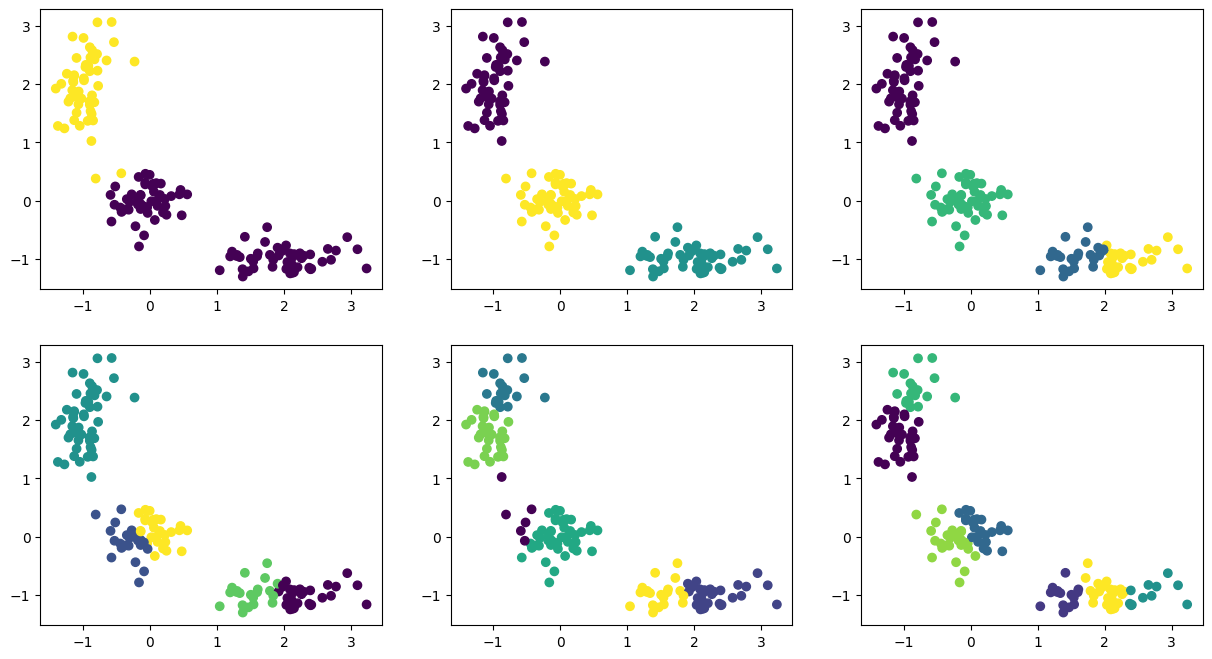

In [22]:
plt.figure(figsize = (15, 8))

for n_c in range(2, 8):
    kmeans = KMeans(n_clusters=n_c)
    kmeans = kmeans.fit(X)

    plt.subplot(2, 3, n_c - 1)
    plt.scatter(X[:,0], X[:,1], c = kmeans.labels_)

plt.show()

## Применим **Иерархическую кластеризацию**

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0
 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]


Text(0, 0.5, 'y')

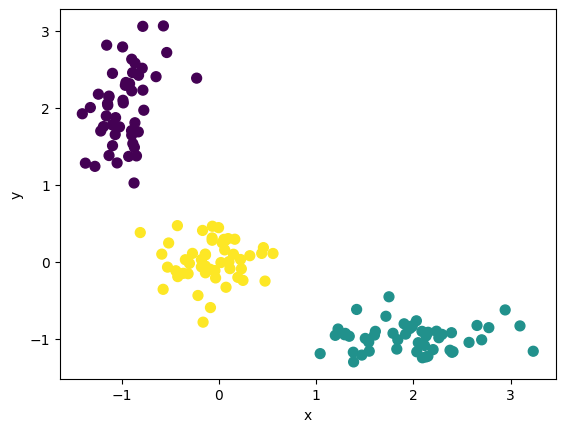

In [24]:
hie = AgglomerativeClustering(n_clusters=3, linkage='ward')
hie.fit(X)
print(hie.labels_) # номер кластера для каждого объекта из трейна

plt.scatter(X[:,0], X[:,1], c = hie.labels_, s = 50, cmap = 'viridis')
plt.xlabel('x')
plt.ylabel('y')

### Построим дендрограмму

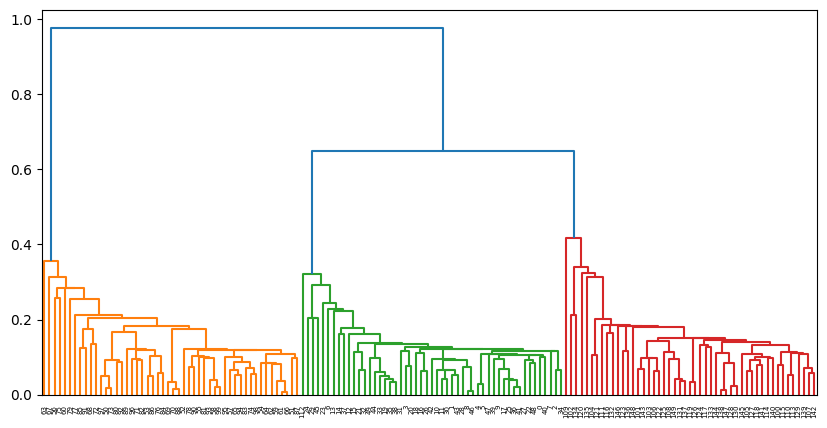

In [20]:
distance_mat = pdist(X) # pdist посчитает нам верхний треугольник матрицы попарных расстояний

Z = hierarchy.linkage(distance_mat, 'single') 
# linkage - реализация агломеративного (иерархического) алгоритма. 
# 'single' - считаем расстояние между двумя ближайшими точками
plt.figure(figsize = (10, 5))
dn = hierarchy.dendrogram(Z, color_threshold=0.6)
# color_threshold - порог деления на кластеры по цветам на дендрограмме

## Применим **DBSCAN (Density-Based Clustering)**

[Ссылка на визуализацию DBSCAN](https://www.naftaliharris.com/blog/visualizing-dbscan-clustering/)

### Density-based spatial clustering of applications with noise

Это алгоритм, основанный на плотности — если дан набор объектов в некотором пространстве, алгоритм группирует вместе объекты, которые расположены близко и помечает как выбросы объекты, которые находятся в областях с малой плотностью (ближайшие соседи которых лежат далеко).

Посмотрим на результаты кластеризации при разном выборе параметров `eps` и `min_samples`.

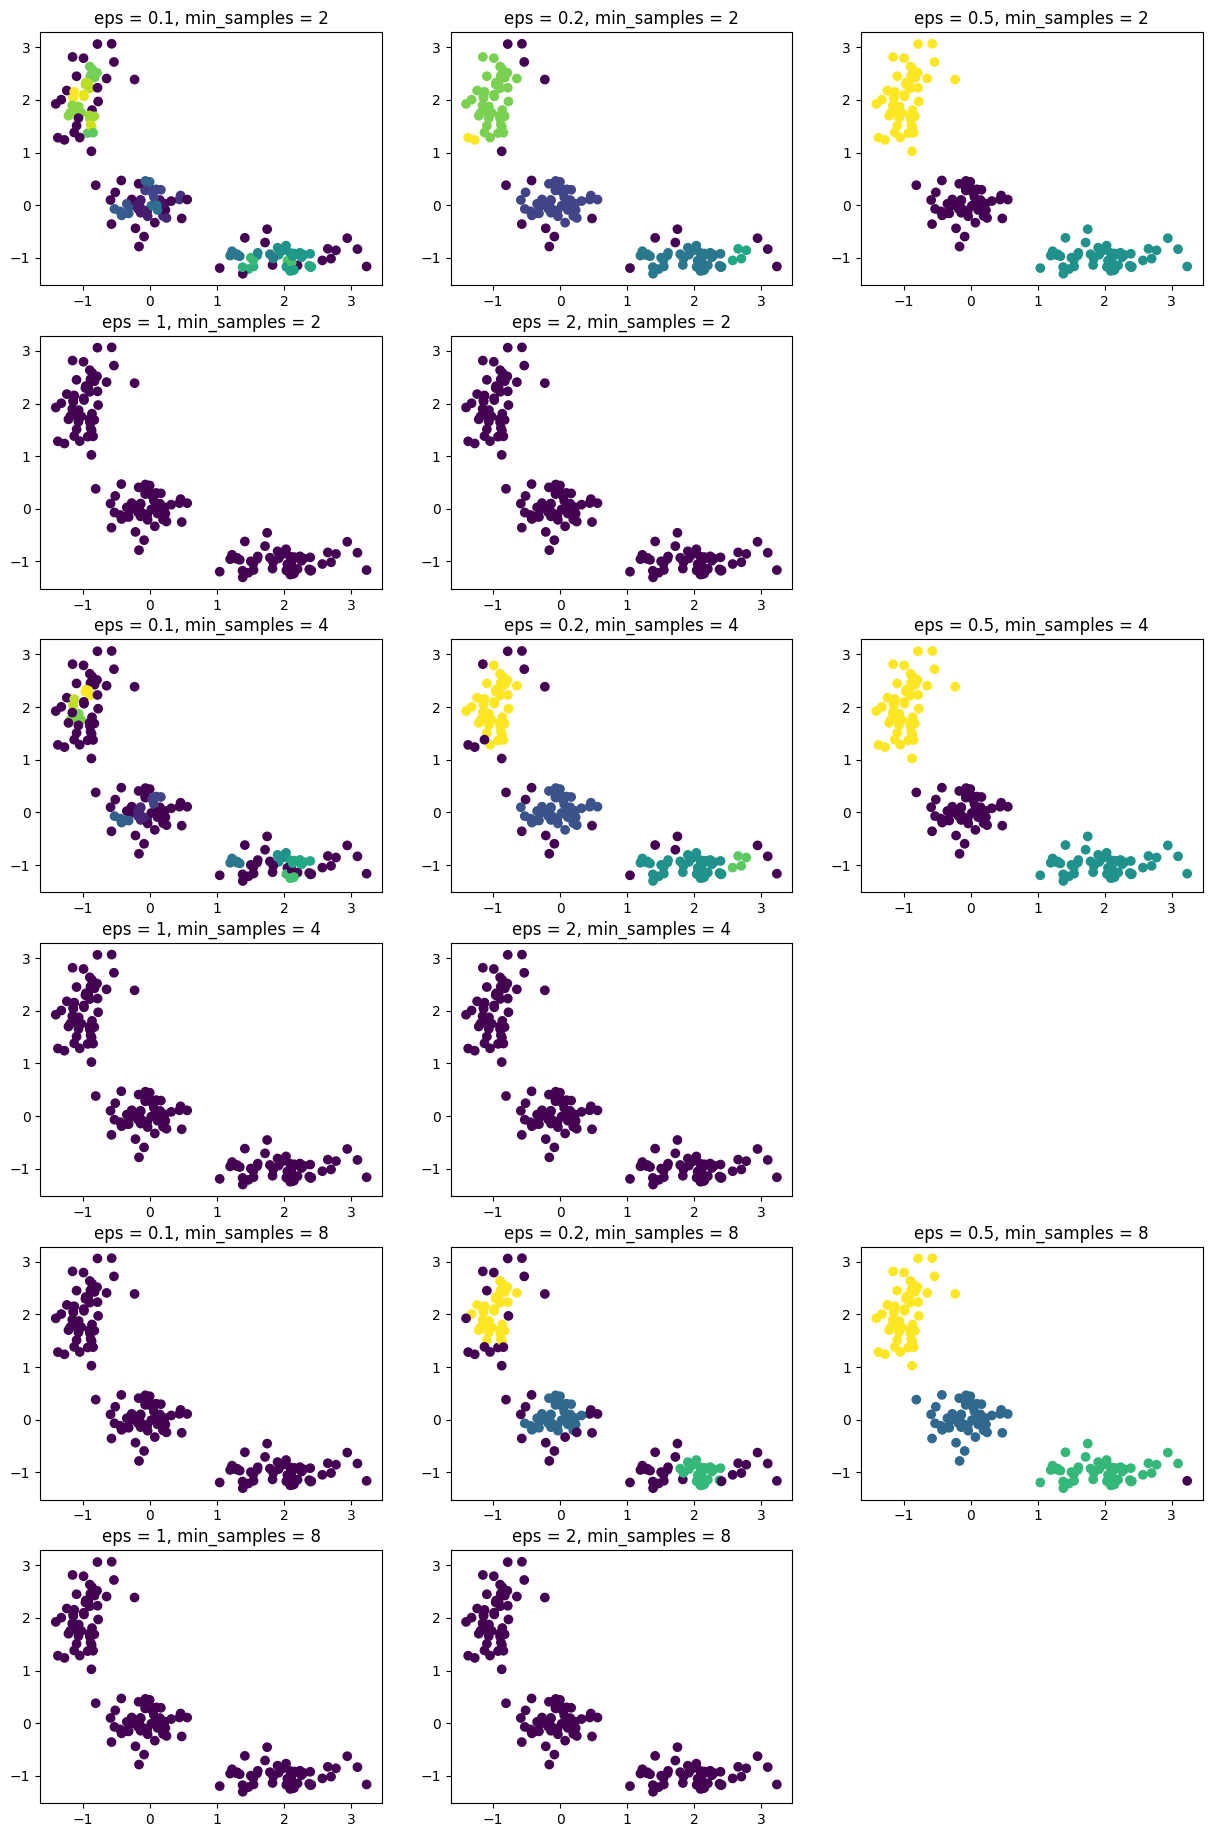

In [26]:
plt.figure(figsize = (15, 23))
i = 1
for samples in [2, 4, 8]:
    for e in [0.1, 0.2, 0.5, 1, 2]:
        dbscan = DBSCAN(eps = e, min_samples=samples)
        clusters = dbscan.fit_predict(X)
        plt.subplot(6, 3, i)
        plt.scatter(X[:, 0], X[:, 1], c = clusters)
        plt.title(f'eps = {e}, min_samples = {samples}')
        i += 1
    i += 1
plt.show()

## Сгенерируем датасет из трех концентрических окружностей

In [27]:
from sklearn.datasets import make_circles
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

<Axes: xlabel='x1', ylabel='x2'>

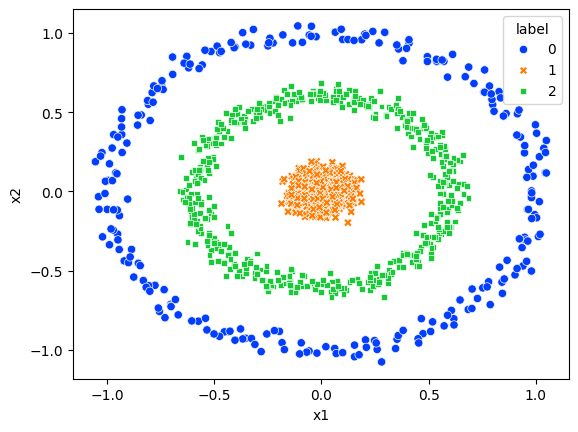

In [28]:
X_small, y_small = make_circles(n_samples=(250,500), random_state=3, noise=0.04, factor = 0.1)
X_large, y_large = make_circles(n_samples=(250,500), random_state=3, noise=0.04, factor = 0.6)
y_large[y_large==1] = 2

df = pd.DataFrame(np.vstack([X_small,X_large]),columns=['x1','x2'])
df['label'] = np.hstack([y_small,y_large])
df.label.value_counts()
sns.scatterplot(data=df,x='x1',y='x2',hue='label',style='label',palette="bright")

In [29]:
x1 = np.expand_dims(df['x1'].values, axis=1)
x2 = np.expand_dims(df['x2'].values, axis=1)
X = np.concatenate((x1,x2), axis=1)
y = df['label'].values

## Применим K-Means

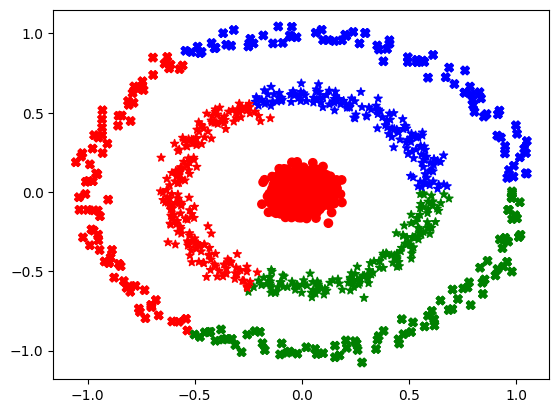

In [31]:
from sklearn.cluster import KMeans

clustering = KMeans(n_clusters = 3).fit(X)

colors = ['r','g','b']
colors = np.array([colors[label] for label in clustering.labels_])
plt.scatter(X[y==0, 0], X[y==0, 1], c=colors[y==0], marker='X')
plt.scatter(X[y==1, 0], X[y==1, 1], c=colors[y==1], marker='o')
plt.scatter(X[y==2, 0], X[y==2, 1], c=colors[y==2], marker='*')
plt.show()

## Применим иерархическую кластеризацию

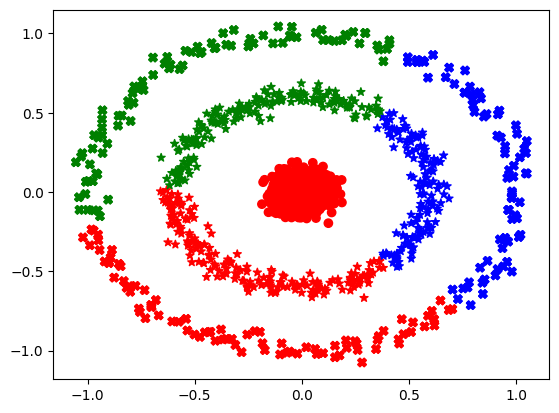

In [33]:
from sklearn.cluster import AgglomerativeClustering

clustering = AgglomerativeClustering(n_clusters=3, linkage='ward').fit(X)

colors = ['r','g','b']
colors = np.array([colors[label] for label in clustering.labels_])
plt.scatter(X[y==0, 0], X[y==0, 1], c=colors[y==0], marker='X')
plt.scatter(X[y==1, 0], X[y==1, 1], c=colors[y==1], marker='o')
plt.scatter(X[y==2, 0], X[y==2, 1], c=colors[y==2], marker='*')
plt.show()

## Применим DBCAN

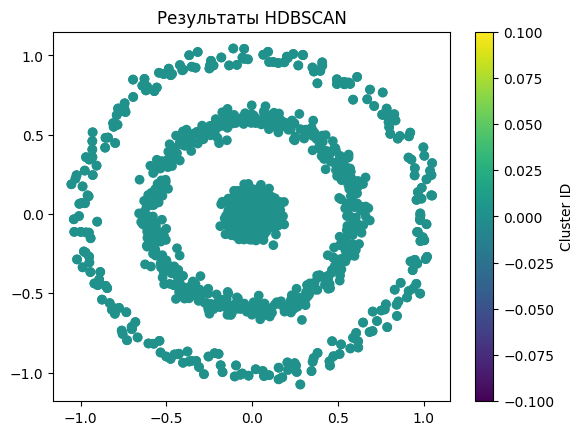

In [47]:
from sklearn.cluster import DBSCAN

clustering = DBSCAN().fit(X)

plt.scatter(X[:, 0], X[:, 1], c=clustering.labels_, cmap='viridis')
plt.colorbar(label='Cluster ID')
plt.title('Результаты HDBSCAN')
plt.show()

## Применим HDBSCAN

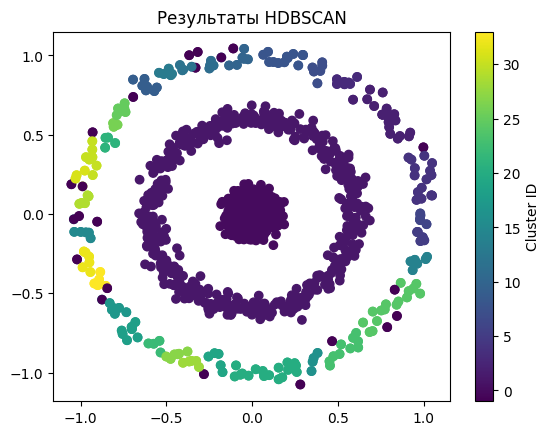

In [46]:
from sklearn.cluster import HDBSCAN

clustering = HDBSCAN().fit(X)

plt.scatter(X[:, 0], X[:, 1], c=clustering.labels_, cmap='viridis')
plt.colorbar(label='Cluster ID')
plt.title('Результаты HDBSCAN')
plt.show()

## Применим **спектральную кластеризацию**

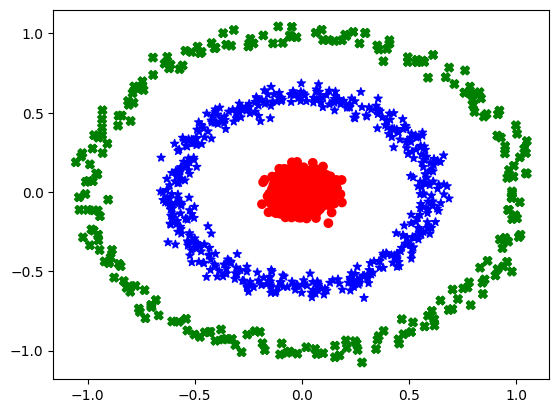

In [32]:
from sklearn.cluster import SpectralClustering

clustering = SpectralClustering(n_clusters=3, gamma=100).fit(X)

colors = ['r','g','b']
colors = np.array([colors[label] for label in clustering.labels_])
plt.scatter(X[y==0, 0], X[y==0, 1], c=colors[y==0], marker='X')
plt.scatter(X[y==1, 0], X[y==1, 1], c=colors[y==1], marker='o')
plt.scatter(X[y==2, 0], X[y==2, 1], c=colors[y==2], marker='*')
plt.show()